In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
import pandas as pd
import json

An example of the training data, consisting of $N$ hadronization events (in the dataset below $N = 10,000$), is:
$$
\boldsymbol{z} = 
  \begin{pmatrix}
    \boldsymbol{z}_1 = 
    \begin{pmatrix} 
        \big\{ \texttt{idOld}^{1}, \texttt{idNew}^1, m_T^{h_1},p_x^{h_1}, p_y^{h_1}, z^{h_1}_{\text{accept}}, z^{1, h_1}_{\text{reject}}, z^{2, h_1}_{\text{reject}}, \cdots, 									  z^{n_{h_1}, h_1}_{\text{reject}}\big\} \\
        \big\{  \texttt{idOld}^{2}, \texttt{idNew}^2, m_T^{h_2}, p_x^{h_2}, p_y, z^{h_2}_{\text{accept}}, z^{1, h_2}_{\text{reject}}, z^{2, h_2}_{\text{reject}}, \cdots, z^{n_{h_2}, h_2}_{\text{reject}} \big\} \\	
        \big\{ \texttt{idOld}^{3}, \texttt{idNew}^3, m_T^{h_3}, p_x^{h_3}, p_y^{h_3}, z^{h_3}_{\text{accept}}, z^{1, h_3}_{\text{reject}}, z^{2, h_3}_{\text{reject}}, \cdots, z^{n_{h_3}, h_3}_{\text{reject}} \big\} 
        \end{pmatrix}_1 \\
    \boldsymbol{z}_2 = 
    \begin{pmatrix} 
      \big\{ \texttt{idOld}^{1}, \texttt{idNew}^1, m_T^{h_1}, p_x^{h_1}, p_y^{h_1}, z^{h_1}_{\text{accept}}, z^{1, h_1}_{\text{reject}}, z^{2, h_1}_{\text{reject}}, \cdots, z^{n_{h_1}, h_1}_{\text{reject}}\big\} \\
      \vdots \\	
      \big\{ \texttt{idOld}^{4}, \texttt{idNew}^4, m_T^{h_4}, p_x^{h_4}, p_y^{h_4}, z^{h_4}_{\text{accept}}, z^{1, h_4}_{\text{reject}}, z^{2, h_4}_{\text{reject}}, \cdots, z^{n_{h_4}, h_4}_{\text{reject}} \big\} 
      \end{pmatrix}_2 \\
      \vdots \\
    \boldsymbol{z}_N = \cdots
  \end{pmatrix},
$$
$$
\boldsymbol{y}_\text{sim} = 
  \begin{pmatrix}
    \boldsymbol{y}_1 = N_{h,1} = 3\\
    \boldsymbol{y}_2 = N_{h,2} = 4 \\
    \vdots \\
    \boldsymbol{y}_N = N_{h,N} = 2
\end{pmatrix}
$$
Note that each array $\boldsymbol{z}_i$ is zero-padded to a fixed length of size $105$ and each accept-reject array is zero-padded to a fixed length of size $101$ (the maximum number of rejections is 100).

The hadrons dataset consists of an array:

$X =
\begin{pmatrix}
\mathbf{x}_1 =
\begin{pmatrix}
\{ p_x^{(1)},\ p_y^{(1)},\ p_z^{(1)},\ E^{(1)}?,\ m^{(1)}?,\ \mathrm{PDG}^{(1)}? \} \\
\{ p_x^{(2)},\ p_y^{(2)},\ p_z^{(2)},\ E^{(2)},\ m^{(2)},\ \mathrm{PDG}^{(2)} \} \\
\vdots \\
\{ p_x^{(N_1)},\ p_y^{(N_1)},\ p_z^{(N_1)},\ E^{(N_1)},\ m^{(N_1)},\ \mathrm{PDG}^{(N_1)} \}\\
\{0,\dots,0 \}\\
\vdots\\
\{0,\dots,0 \}\\
\end{pmatrix}_1
\\[1em]
\mathbf{x}_2 =
\begin{pmatrix}
\{ p_x^{(1)},\ p_y^{(1)},\ p_z^{(1)},\ E^{(1)},\ m^{(1)},\ \mathrm{PDG}^{(1)} \} \\
\vdots \\
\{ p_x^{(N_2)},\ p_y^{(N_2)},\ p_z^{(N_2)},\ E^{(N_2)},\ m^{(N_2)},\ \mathrm{PDG}^{(N_2)} \}\\
\{0,\dots,0 \}\\
\vdots\\
\{0,\dots,0 \}\\
\end{pmatrix}_2
\\
\vdots \\
\mathbf{x}_M = \cdots
\end{pmatrix}$

Where:  
- $M$ = total number of events in the dataset.  
- $N_i$ = number of particles in event $i$.  
- $p_x, p_y, p_z$ = momentum components in GeV.  
- $E$ = total energy in GeV, satisfying $E^2 = p_x^2 + p_y^2 + p_z^2 + m^2$.  
- $m$ = rest mass in GeV.  
- $\mathrm{PDG}$ = Particle Data Group ID (integer), sign indicates particle (+) or antiparticle (−).
- The hadrons inside each event are zero padded to a constant length



In [2]:
# Paths to the datasets
exp_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.17_aU0_aS0_aC0_aB0_aH0.97_bD0.88_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.25_N_1.0e+05_hadrons.npy' #!NOTE: this array is doubled

sim_hadrons_PATH       = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.1275_aU0_aS0_aC0_aB0_aH0.97_bD0.905_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.27125_N_1.0e+05_hadrons.npy'

sim_accept_reject_PATH = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.1275_aU0_aS0_aC0_aB0_aH0.97_bD0.905_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.27125_N_1.0e+05_id_mT2_accept_reject_z.npy'

sim_fPrel_PATH         = '/pscratch/sd/l/ljpuslar/RSA/RSA/data/structured_data/pgun_uubar_allhadsigma_a0.68_b0.98_aD0.1275_aU0_aS0_aC0_aB0_aH0.97_bD0.905_bU0.98_bS0.98_bC0.98_bB0.98_bH0.98_sigma_0.27125_N_1.0e+05_fPrel.npy'


In [15]:
# Load the arrays
exp_hadrons       = np.load(exp_hadrons_PATH, mmap_mode="r")
sim_hadrons       = np.load(sim_hadrons_PATH, mmap_mode="r")
sim_accept_reject = np.load(sim_accept_reject_PATH, mmap_mode = "r")
sim_fPrel         = np.load(sim_fPrel_PATH, mmap_mode = "r")

# Print dataset shapes
print('Experimental observable shape:', exp_hadrons.shape)
# print('Experimental observable:', exp_hadrons[0,:]) #the first 10 hadrons and their 5 properties
print('Simulated observable shape:', sim_hadrons.shape)
print('Simulated z shape:', sim_accept_reject.shape)
print('Simulated fPrel shape:', sim_fPrel.shape)

# Restrict to a subset of the full dataset (for memory)
N_events = int(100000)
N_target = min(int(100000), len(exp_hadrons)) # the number of events in the experimental dataset
print('N_target: ', N_target)

# Extract the hadron multiplicity
# exp_mult = np.array([len(exp_hadrons[i,:][np.abs(exp_hadrons[i,:,0]) > 0.0]) for i in range(N_target)])
mask_exp = np.abs(exp_hadrons[:N_target, :, 0]) > 0.0
exp_mult = np.sum(mask_exp, axis=1)
mask_sim = np.abs(sim_hadrons[:N_events, :, 0]) > 0.0
sim_mult = np.sum(mask_sim, axis=1)

# Convert into torch objects
sim_mult          = torch.Tensor(sim_mult[0:N_events].copy())
sim_accept_reject = torch.Tensor(sim_accept_reject[0:N_events].copy())
sim_fPrel         = torch.Tensor(sim_fPrel[0:N_events].copy())
exp_mult          = torch.Tensor(exp_mult[0:N_target].copy())

# Check the accepted z-values, if z == 1 reduce it by epsilon (a very nasty bug to find).
# The a-coefficient when computing the likelihood has a term proportional to log(1-z). If 
# z = 1, this term diverges to -inf and completely destroys the backward pass.
epsilon = 1e-5
sim_accept_reject[:,:,2:][sim_accept_reject[:,:,2:] == 1] = 1 - epsilon # Do not change pid values!


Experimental observable shape: (100000, 75, 6)
Simulated observable shape: (100000, 75, 6)
Simulated z shape: (100000, 250, 105)
Simulated fPrel shape: (100000, 250, 100)
N_target:  100000


In [16]:
# # Load the hadron data
# exp_hadrons = np.load(exp_hadrons_PATH, mmap_mode="r")
# sim_hadrons = np.load(sim_hadrons_PATH, mmap_mode="r")

# print('Experimental hadron data shape:', exp_hadrons.shape)
# print('Simulated hadron data shape:', sim_hadrons.shape)

# # Extract the hadron multiplicity
# N = 10000
# exp_mult = np.array([len(exp_hadrons[i,:][np.abs(exp_hadrons[i,:,0]) > 0.0]) for i in range(N)])
# sim_mult = np.array([len(sim_hadrons[i,:][np.abs(sim_hadrons[i,:,0]) > 0.0]) for i in range(N)])

# # Find the maximum multiplicity
# min_mult = min(exp_mult.min(), sim_mult.min())
# max_mult = max(exp_mult.max(), sim_mult.max())
# print("Max multiplicity:", max_mult)

# # Resize the zero-padding to the maximum multiplicity
# exp_hadrons = exp_hadrons[:, :max_mult, :]
# sim_hadrons = sim_hadrons[:, :max_mult, :]

# # Extract (px, py, pz)
# px_exp, py_exp, pz_exp, = exp_hadrons[..., 0], exp_hadrons[..., 1], exp_hadrons[..., 2]
# px_sim, py_sim, pz_sim = sim_hadrons[..., 0], sim_hadrons[..., 1], sim_hadrons[..., 2]


# # Create masks for non-zero momentum entries
# mask_exp = (px_exp != 0) | (py_exp != 0) | (pz_exp != 0)
# mask_sim = (px_sim != 0) | (py_sim != 0) | (pz_sim != 0)

# # Calculate transverse momentum (pT)
# pt_exp = np.sqrt(px_exp**2 + py_exp**2)
# pt_sim = np.sqrt(px_sim**2 + py_sim**2)

# # Initialize arrays for the results with zeros
# phi_exp = np.zeros_like(pt_exp)
# phi_sim = np.zeros_like(pt_sim)
# eta_exp = np.zeros_like(pt_exp)
# eta_sim = np.zeros_like(pt_sim)

# # Apply the calculations only where the mask is True (non-zero momentum)
# phi_exp[mask_exp] = np.arctan2(py_exp[mask_exp], px_exp[mask_exp])
# phi_sim[mask_sim] = np.arctan2(py_sim[mask_sim], px_sim[mask_sim])

# theta_exp = np.arctan2(pt_exp[mask_exp], pz_exp[mask_exp])
# theta_sim = np.arctan2(pt_sim[mask_sim], pz_sim[mask_sim])

# eta_exp[mask_exp] = -np.log(np.tan(theta_exp / 2))
# eta_sim[mask_sim] = -np.log(np.tan(theta_sim / 2))

# # Define the new angular observable array (pT, phi, eta)
# exp_obs = np.stack([pt_exp, phi_exp, eta_exp], axis=-1)
# sim_obs = np.stack([pt_sim, phi_sim, eta_sim], axis=-1)

# # Print dataset shapes
# print('Experimental observable shape:', exp_obs.shape)
# print('Simulated observable shape:', sim_obs.shape)



In [17]:
def charged_mask_from_pdg(pdg_ids, charged=1):
    """
    Minimal PDG charge mask for common stable hadrons.
    Extend with a full PDG charge table if needed.
    """
    charged_set = {
        -3334,  # anti-Omega+
        -3324,  # anti-Xi*+
        -3224,  # anti-Sigma*-
        -3114,  # anti-Sigma*+
        -2214,  # anti-Delta-
        -1114,  # anti-Delta+
        -323,   # anti-K*-
        -321,   # K-
        -213,   # rho-
        -211,   # pi-
        211,   # pi+
        213,   # rho+
        321,   # K+
        323,   # K*+
        1114,  # Delta-
        2212,  # proton
        2214,  # Delta+
        2224,  # Delta++
        3112,  # Sigma-
        3114,  # Sigma*-
        3222,  # Sigma+
        3224,  # Sigma*+
        3312,  # Xi-
        3314,  # Xi*-
        3334,  # Omega-
    }
    
    return np.isin(pdg_ids, list(charged_set))

exp_hadrons_temp = exp_hadrons[:N_events]
sim_hadrons_temp = sim_hadrons[:N_events]   

px_exp, py_exp, pz_exp = exp_hadrons_temp[..., 0], exp_hadrons_temp[..., 1], exp_hadrons_temp[..., 2]
E_exp, m_exp, pid_exp = exp_hadrons_temp[..., 3], exp_hadrons_temp[..., 4], exp_hadrons_temp[..., 5]

px_sim, py_sim, pz_sim = sim_hadrons_temp[..., 0], sim_hadrons_temp[..., 1], sim_hadrons_temp[..., 2]
E_sim, m_sim, pid_sim = sim_hadrons_temp[..., 3], sim_hadrons_temp[..., 4], sim_hadrons_temp[..., 5]

p_mag_exp = np.sqrt(px_exp**2 + py_exp**2 + pz_exp**2)
p_mag_sim = np.sqrt(px_sim**2 + py_sim**2 + pz_sim**2)

# Charged masks
charged_mask_exp = charged_mask_from_pdg(pid_exp) & (pid_exp != 0)
charged_mask_sim = charged_mask_from_pdg(pid_sim) & (pid_sim != 0)
uncharged_mask_exp = ~charged_mask_exp & (pid_exp != 0)
uncharged_mask_sim = ~charged_mask_sim & (pid_sim != 0)

# --- Charged-only views (same shape as originals; others set to 0.0) ---
px_exp_charged = np.where(charged_mask_exp, px_exp, 0.0)
py_exp_charged = np.where(charged_mask_exp, py_exp, 0.0)
pz_exp_charged = np.where(charged_mask_exp, pz_exp, 0.0)
E_exp_charged  = np.where(charged_mask_exp,  E_exp, 0.0)
m_exp_charged  = np.where(charged_mask_exp,  m_exp, 0.0)

px_sim_charged = np.where(charged_mask_sim, px_sim, 0.0)
py_sim_charged = np.where(charged_mask_sim, py_sim, 0.0)
pz_sim_charged = np.where(charged_mask_sim, pz_sim, 0.0)
E_sim_charged  = np.where(charged_mask_sim,  E_sim, 0.0)
m_sim_charged  = np.where(charged_mask_sim,  m_sim, 0.0)

# --- Uncharged-only views (same shape; charged entries set to 0.0) ---
px_exp_uncharged = np.where(uncharged_mask_exp, px_exp, 0.0)
py_exp_uncharged = np.where(uncharged_mask_exp, py_exp, 0.0)
pz_exp_uncharged = np.where(uncharged_mask_exp, pz_exp, 0.0)
E_exp_uncharged  = np.where(uncharged_mask_exp,  E_exp, 0.0)
m_exp_uncharged  = np.where(uncharged_mask_exp,  m_exp, 0.0)

px_sim_uncharged = np.where(uncharged_mask_sim, px_sim, 0.0)
py_sim_uncharged = np.where(uncharged_mask_sim, py_sim, 0.0)
pz_sim_uncharged = np.where(uncharged_mask_sim, pz_sim, 0.0)
E_sim_uncharged  = np.where(uncharged_mask_sim,  E_sim, 0.0)
m_sim_uncharged  = np.where(uncharged_mask_sim,  m_sim, 0.0)


# print(px_exp_charged.shape)
# print(px_exp_charged[0])
# print(px_exp_uncharged[0])

charged_mult_exp = np.sum(charged_mask_exp, axis=1)
charged_mult_sim = np.sum(charged_mask_sim, axis=1)

uncharged_mult_exp = np.sum(uncharged_mask_exp, axis=1)
uncharged_mult_sim = np.sum(uncharged_mask_sim, axis=1)

mask = np.abs(exp_hadrons_temp[:, :, 0]) > 0.0
mult_exp = np.sum(mask, axis=1)
mask = np.abs(sim_hadrons_temp[:, :, 0]) > 0.0
mult_sim = np.sum(mask, axis=1)

p_mag_exp = np.sqrt(px_exp**2 + py_exp**2 + pz_exp**2)
p_mag_sim = np.sqrt(px_sim**2 + py_sim**2 + pz_sim**2)

p_frac_exp = p_mag_exp / np.sum(p_mag_exp, axis=1, keepdims=True)
p_frac_sim = p_mag_sim / np.sum(p_mag_sim, axis=1, keepdims=True)

print('charged_mult_exp shape: ', charged_mult_exp.shape)
print('charged_mult_sim shape: ', charged_mult_sim.shape)
print('uncharged_mult_exp shape: ', uncharged_mult_exp.shape)
print('uncharged_mult_sim shape: ', uncharged_mult_sim.shape)
print('mult_exp shape: ', mult_exp.shape)
print('mult_sim shape: ', mult_sim.shape)
print()
print('p_frac_exp shape: ', p_frac_exp.shape)
print('p_frac_sim shape: ', p_frac_sim.shape)



charged_mult_exp shape:  (100000,)
charged_mult_sim shape:  (100000,)
uncharged_mult_exp shape:  (100000,)
uncharged_mult_sim shape:  (100000,)
mult_exp shape:  (100000,)
mult_sim shape:  (100000,)

p_frac_exp shape:  (100000, 75)
p_frac_sim shape:  (100000, 75)


In [18]:
def momentum_fraction_moments(p_frac, charged_mask):
    """
    Compute first 3 moments (mean, variance, skewness) of momentum fractions
    for the charged subset of particles in each event.

    Parameters
    ----------
    p_frac : array, shape (n_events, n_particles)
        Momentum fractions per event (e.g., |p_i| / sum|p|).
    charged_mask : bool array of same shape
        True where particle is charged, False otherwise.

    Returns
    -------
    mean : (n_events,) array
        First moment (mean) over charged subset.
    m2_raw : (n_events,) array
        Second raw moment <z^2>.
    var : (n_events,) array
        Variance <(z - mean)^2>.
    skew : (n_events,) array
        Skewness (third central moment normalized by variance^(3/2)).
    """
    mask = charged_mask.astype(bool)
    counts = np.sum(mask, axis=1, keepdims=True)
    safe = counts > 0
    eps = 1e-12

    # First moment <z>
    m1 = np.zeros_like(counts, dtype=float)
    m1[safe] = np.sum(p_frac * mask, axis=1, keepdims=True)[safe] / counts[safe]

    # Second raw moment <z^2>
    m2_raw = np.zeros_like(counts, dtype=float)
    m2_raw[safe] = np.sum((p_frac**2) * mask, axis=1, keepdims=True)[safe] / counts[safe]

    # Variance <(z - m1)^2>
    var = np.zeros_like(counts, dtype=float)
    var[safe] = np.sum(((p_frac - m1)**2) * mask, axis=1, keepdims=True)[safe] / counts[safe]

    # Skewness
    skew = np.zeros_like(counts, dtype=float)
    skew[safe] = np.sum((((p_frac - m1) / (np.sqrt(var) + eps))**3) * mask,
                         axis=1, keepdims=True)[safe] / counts[safe]

    return m1.ravel(), m2_raw.ravel(), var.ravel(), skew.ravel()


# --- Experimental data ---
p_charged_1mom_exp, p_charged_2raw_exp, p_charged_var_exp, p_charged_skew_exp = \
    momentum_fraction_moments(p_frac_exp, charged_mask_exp)

# --- Simulated data ---
p_charged_1mom_sim, p_charged_2raw_sim, p_charged_var_sim, p_charged_skew_sim = \
    momentum_fraction_moments(p_frac_sim, charged_mask_sim)

# Debug print
print("Experimental mean (m1) shape: ", p_charged_1mom_exp.shape)
print("Experimental variance shape: ", p_charged_var_exp.shape)
print("Experimental skewness shape: ", p_charged_skew_exp.shape)

print("Simulated mean (m1) shape: ", p_charged_1mom_sim.shape)
print("Simulated variance shape: ", p_charged_var_sim.shape)
print("Simulated skewness shape: ", p_charged_skew_sim.shape)


# Mask for all real particles (exclude padding)
all_mask_exp = pid_exp != 0
all_mask_sim = pid_sim != 0

p_all_1mom_exp, p_all_2raw_exp, p_all_var_exp, p_all_skew_exp = \
    momentum_fraction_moments(p_frac_exp, all_mask_exp)

p_all_1mom_sim, p_all_2raw_sim, p_all_var_sim, p_all_skew_sim = \
    momentum_fraction_moments(p_frac_sim, all_mask_sim)

Experimental mean (m1) shape:  (100000,)
Experimental variance shape:  (100000,)
Experimental skewness shape:  (100000,)
Simulated mean (m1) shape:  (100000,)
Simulated variance shape:  (100000,)
Simulated skewness shape:  (100000,)


In [19]:

exp_obs_combined = np.stack([charged_mult_exp, mult_exp, p_charged_1mom_exp, p_charged_var_exp, p_charged_skew_exp, p_all_1mom_exp, p_all_var_exp, p_all_skew_exp], axis=-1)
sim_obs_combined = np.stack([charged_mult_sim, mult_sim, p_charged_1mom_sim, p_charged_var_sim, p_charged_skew_sim, p_all_1mom_sim, p_all_var_sim, p_all_skew_sim], axis=-1)
print('exp_obs shape: ', exp_obs_combined.shape)
print(exp_obs_combined[0])



exp_obs shape:  (100000, 8)
[7.00000000e+00 1.10000000e+01 4.78848659e-02 4.70221816e-03
 1.58026683e+00 9.09090909e-02 1.14569175e-02 9.55290500e-01]


In [20]:

import torch
from torch import nn


class LundWeight(nn.Module):
    def __init__(self, params_base, params, over_sample_factor, device):
        super(LundWeight, self).__init__()
        """
        LundWeight class for computing event weights for the Lund fragmentation function

        Args:
            params_base (torch.Tensor): ------ Base parameters for the Lund fragmentation function
            params (torch.Tensor): ----------- Parameters to be reweighted for the Lund fragmentation function
            over_sample_factor (int): -------- Over-sampling factor for the rejected events
        """

        # Device
        self.device = device

        # Intialize the module parameters
        self.params_base = params_base
        self.params = params

        if "sigma" in self.params and self.params["sigma"] is not None:
            #!NOTE: don't change variable name
            self.sigma_alt = torch.nn.Parameter(self.params['sigma'].to(self.device), requires_grad = True)

        # Initialize the params dictionary
        # Two lookups (one for 'a', one for 'b')
        #!NOTE: don't change variable name
        self.a_lookup_alt = PIDLookup(params_base, params, prefix='a', device=self.device, alt=True)
        self.b_lookup_alt = PIDLookup(params_base, params, prefix='b', device=self.device, alt=True)
        self.a_lookup_base = PIDLookup(params_base, params, prefix='a', device=self.device, alt=False)
        self.b_lookup_base = PIDLookup(params_base, params, prefix='b', device=self.device, alt=False)

        # Register pid_keys to use for gradient saving
        self.pid_keys = self.a_lookup_alt.pid_keys

        # Initialize the over-sampling factor 
        self.over_sample_factor = over_sample_factor

        # Constants for numerical stability checks
        self.AFROMZERO = 0.02
        self.EXPMAX = 50.
        self.AFROMC = 0.01


    def zMaxCalc(self, a, b, c):
        """
        Estimate the maximum value of z for the Lund fragmentation function
    
        Args:
            a (torch.Tensor): --------------- Parameter a
            b (torch.Tensor): --------------- Parameter b
            c (torch.Tensor): --------------- Parameter c
        
        Returns:
            zMax (torch.Tensor): Estimate for the maximum value of z given (a,b,c)
        """
        # Normalization for Lund fragmentation function so that f <= 1.
        # Special cases for a = 0 and a = c.
        aIsZero = (a < self.AFROMZERO)
        aIsC = (torch.abs(a - c) < self.AFROMC)
        
        # Initialize zMax tensor with the same shape as inputs
        zMax = torch.zeros_like(a, dtype = a.dtype)
        
        # Handle special case where a is zero
        zero_mask = aIsZero
        zMax[zero_mask] = torch.where(c[zero_mask] > b[zero_mask], b[zero_mask] / c[zero_mask], torch.ones_like(zMax[zero_mask], dtype = a.dtype))
        
        # Handle special case where a is essentially equal to c
        c_mask = aIsC & ~zero_mask
        zMax[c_mask] = b[c_mask] / (b[c_mask] + c[c_mask])
        
        # Handle the general case
        general_mask = ~(zero_mask | c_mask)
        if general_mask.any():
            # Compute zMax for the general case
            b_sub = b[general_mask]
            c_sub = c[general_mask]
            a_sub = a[general_mask]
            
            zMax_general = 0.5 * (b_sub + c_sub - torch.sqrt(torch.pow(b_sub - c_sub, 2) + 4 * a_sub * b_sub)) / (c_sub - a_sub)
            
            # Check for NaN values
            if torch.isnan(zMax_general).any():
                print('zMax_1', zMax_general)
                print('a', a[general_mask], 'b', b[general_mask], 'c', c[general_mask])
                exit()
            
            # Adjust zMax in numerically unstable regions 
            zMax_general = torch.where((zMax_general > 0.9999) & (b_sub > 100.), torch.min(zMax_general, 1. - a_sub / b_sub), zMax_general)
            zMax[general_mask] = zMax_general
        
        return zMax

    def likelihood(self, z, mT, a, b, c, z_mask = None, mT_mask = None, a_mask = None, b_mask = None, c_mask = None):
        """
        Compute the likelihood of the Lund fragmentation function

        Args:
            z (torch.Tensor): --------------- Input tensor
            mT (torch.Tensor): -------------- Transverse mass tensor (can be different shape from z)
            a (torch.Tensor): --------------- Parameter a
            b (torch.Tensor): --------------- Parameter b
            c (torch.Tensor): --------------- Parameter c (default: torch.tensor(1., requires_grad=True))
            z_mask (torch.Tensor, optional):  Boolean mask tensor for z (default: None)
            mT_mask (torch.Tensor, optional): Boolean mask tensor for mT (default: None)
            a_mask (torch.Tensor, optional): Boolean mask tensor for a (default: None)
            b_mask (torch.Tensor, optional): Boolean mask tensor for b (default: None)
            c_mask (torch.Tensor, optional): Boolean mask tensor for c (default: None)

        Returns:
            likelihood (torch.Tensor): Computed likelihood values (shape determined by broadcasting rules)
        """
        # Determine the shape after broadcasting
        broadcast_shape = torch.broadcast_shapes(z.shape, mT.shape, a.shape, b.shape, c.shape)
        # If no masks are provided, consider all elements
        if z_mask is None:
            z_mask = torch.ones(z.shape, dtype=torch.bool, device=z.device)
        if mT_mask is None:
            mT_mask = torch.ones(mT.shape, dtype=torch.bool, device=mT.device)
        if a_mask is None:
            a_mask = torch.ones(a.shape, dtype=torch.bool, device=a.device)
        if b_mask is None:
            b_mask = torch.ones(b.shape, dtype=torch.bool, device=b.device)
        if c_mask is None:
            c_mask = torch.ones(c.shape, dtype=torch.bool, device=c.device)

        # Broadcast z, mT, and their masks to the common shape
        z_broad = z.expand(broadcast_shape)
        mT_broad = mT.expand(broadcast_shape)
        a_broad = a.expand(broadcast_shape)
        b_broad = b.expand(broadcast_shape)
        c_broad = c.expand(broadcast_shape)
        z_mask_broad = z_mask.expand(broadcast_shape)
        mT_mask_broad = mT_mask.expand(broadcast_shape)
        a_mask_broad = a_mask.expand(broadcast_shape)
        b_mask_broad = b_mask.expand(broadcast_shape)
        c_mask_broad = c_mask.expand(broadcast_shape)
    
        # Combine masks
        combined_mask = z_mask_broad & mT_mask_broad & a_mask_broad & b_mask_broad & c_mask_broad
        
        # Create a tensor to store the results, initialized with zeros
        likelihood = torch.zeros(broadcast_shape, dtype=z.dtype, device=z.device)
    
        # Only perform calculations on unmasked elements
        z_unmasked = z_broad[combined_mask]
        mT_unmasked = mT_broad[combined_mask]
        a_unmasked = a_broad[combined_mask]
        b_unmasked = b_broad[combined_mask]
        c_unmasked = c_broad[combined_mask]
    
        # Check if we have any unmasked elements to process
        if z_unmasked.numel() > 0:
            # Adjust b-parameter
            b_exp = b_unmasked * mT_unmasked
            
            # Special case for a = 0.
            aIsZero = (a_unmasked < self.AFROMZERO)
            # Determine position of maximum.
            zMax = self.zMaxCalc(a_unmasked, b_exp, c_unmasked)
            
            # Be careful of -inf values in aCoeff, z is being rounded to exactly 1.
            aCoef = torch.log(1. - z_unmasked) - torch.log(1. - zMax)
            if torch.isneginf(aCoef).any():
                print('aCoef is returning -inf value, please check that all z < 1.')
                print('aCoeff', aCoef)
    
            bCoef = (1. / zMax) - (1. / z_unmasked)
            cCoef = torch.log(zMax) - torch.log(z_unmasked)
            fExp = b_exp * bCoef + c_unmasked * cCoef

            
            # Special cases for a = 0.
            not_zero_mask = ~aIsZero
            fExp[not_zero_mask] = fExp[not_zero_mask] + a_unmasked[not_zero_mask] * aCoef[not_zero_mask]
            
            # Feed through numerical stabilizer
            fVal = torch.exp(torch.clamp(fExp, min=-self.EXPMAX, max=self.EXPMAX))
            
            # Assign computed values back to the likelihood tensor
            likelihood[combined_mask] = fVal

        return likelihood

    def sigma_weights(self, px, py, p_mask):
        weights = torch.ones(px.shape, dtype=px.dtype, device=self.device)
        sigma_base = self.params_base['sigma'] / torch.sqrt(torch.tensor(2.0, device=self.device))
        sigma_target = self.sigma_alt / torch.sqrt(torch.tensor(2.0, device=self.device))
        px, py = px[p_mask], py[p_mask]
        kappa = (torch.pow(px,2) + torch.pow(py,2))/(2 * torch.pow(sigma_base, 2))
        ratio = torch.pow(sigma_base,2)/torch.pow(sigma_target,2)
        weights[p_mask] = ratio * torch.exp(-kappa * (ratio-1))

        return weights.prod(axis=1)


    
    def forward(self, z_mT2_pid, fPrel):
        """
        Forward pass of the weight module -- consists of computing the event weights for a given batch
        of training data.

        Args:
            z_mT2 (torch.Tensor): Tensor containing mT2 and z accept-reject data 
            fPrel (torch.Tensor): Tensor containing fPrel values

        Returns:
            weights (torch.Tensor): Computed event weights
        """
        batch_size = z_mT2_pid.shape[0]
        weights = torch.ones(batch_size, device=self.device)


        # z_mT2_pid: Tensor of shape (B, T, 2)
        pid_old = z_mT2_pid[..., 0].abs().round().long()  # → (B, T)
        pid_new = z_mT2_pid[..., 1].abs().round().long()  # → (B, T)

        # # Extract the (absolute value) pid values
        # Four batched lookups, no Python loops
        a_old_base = self.a_lookup_base(pid_old)
        a_base     = self.a_lookup_base(pid_new)
        b_base     = self.b_lookup_base(pid_new)
        c_base = 1 + a_base - a_old_base

        a_old_alt  = self.a_lookup_alt(pid_old)
        a_alt      = self.a_lookup_alt(pid_new)
        b_alt      = self.b_lookup_alt(pid_new)
        c_alt = 1 + a_alt - a_old_alt

        # Create masks for base and alternate parameters (masks should be the same)
        a_mask = a_base != 0.
        b_mask = b_base != 0.
        c_mask = a_base != 0.

        # Extract the mT2 values 
        # mT2 = torch.tensor(z_mT2_pid[:, :, 2], dtype=a_base.dtype)
        mT2 = z_mT2_pid[:, :, 2].clone().detach().to(dtype=a_base.dtype)

        # Reshape into column tensor
        mT2 = mT2.view(mT2.shape[0], mT2.shape[1], 1)
        # Create a mask for zero values
        mT2_mask = mT2 != 0.

        # Extract the accepted z values
        z_accept = z_mT2_pid[:, :, 5]
        # Reshape into column tensor
        z_accept = z_accept.view(z_accept.shape[0], z_accept.shape[1], 1)
        # Remove any zero values
        z_accept_mask = z_accept != 0.

        # Extract the rejected z values
        z_reject = z_mT2_pid[:, :, 6:]
        # Reshape into column tensor
        z_reject = z_reject.view(z_reject.shape[0], z_reject.shape[1], z_reject.shape[2])
        # Remove any zero values along the event index
        z_reject_mask = z_reject != 0.

        # Extract the rejected fPrel values
        fPrel_reject = fPrel[:, :, 1:]
        fPrel_reject = fPrel_reject.view(fPrel_reject.shape[0], fPrel_reject.shape[1], fPrel_reject.shape[2])
        fPrel_reject_mask = fPrel_reject != 0.

        # Compute the accept and reject weights
        accept_weights = self.likelihood(z_accept, mT2, a_alt, b_alt, c_alt, z_mask = z_accept_mask, mT_mask = mT2_mask, a_mask = a_mask, b_mask = b_mask, c_mask = c_mask) \
                         / self.likelihood(z_accept, mT2, a_base, b_base, c_base, z_mask = z_accept_mask, mT_mask = mT2_mask, a_mask = a_mask, b_mask = b_mask, c_mask = c_mask)    
        reject_weights = ((self.over_sample_factor * (fPrel_reject * fPrel_reject_mask.masked_fill(z_accept_mask == 0, 1))) - self.likelihood(z_reject, mT2, a_alt, b_alt, c_alt, z_mask = z_reject_mask, mT_mask = mT2_mask, a_mask = a_mask, b_mask = b_mask, c_mask = c_mask)) \
                         / ((self.over_sample_factor * (fPrel_reject * fPrel_reject_mask.masked_fill(z_accept_mask == 0, 1))) - self.likelihood(z_reject, mT2, a_base, b_base, c_base, z_mask = z_reject_mask, mT_mask = mT2_mask, a_mask = a_mask, b_mask = b_mask, c_mask = c_mask))

        # Flatten the weights
        accept_weights = (accept_weights * z_accept_mask).masked_fill(z_accept_mask == 0, 1).prod(dim=2).prod(dim=1)
        reject_weights = (reject_weights * z_reject_mask).masked_fill(z_reject_mask == 0, 1).prod(dim=2).prod(dim=1)

        # The final event weight is the product of accepted and rejected weights
        weights = accept_weights * reject_weights

        # Add weights for reweighting sigma_pT
        if getattr(self, "sigma_alt", None) is not None:
            px, py = z_mT2_pid[:, :, 3], z_mT2_pid[:, :, 4]
            p_mask = (px != 0)
            weights_sigma = self.sigma_weights(px,py,p_mask)
            weights = weights * weights_sigma

        return weights


class PIDLookup(nn.Module):
    def __init__(
        self,
        params_base: dict[str, torch.Tensor],
        params:      dict[str, torch.Tensor],
        prefix:      str,               # e.g. 'a' or 'b'
        device:      str = 'cuda',
        alt:         bool = False # True if this is the alternative parameters
    ):
        super().__init__()
        self.device = device

        # For the alternative parameters, the look up table is partly trainable
        if alt:
            # 1) Single pass over both dicts to collect actual PIDs
            all_pids = set()
            # for key in list(params_base.keys()) + list(params.keys()):
            for key in list(params_base.keys()):
                if key.startswith(prefix):
                    pid = int(key[len(prefix):])
                    all_pids.add(pid)

            # 2) Sort and register as a tensor of length V
            self.pid_keys = torch.tensor(
                sorted(all_pids),
                dtype=torch.long,
                device=device
            )                           # shape (V,)
            V = self.pid_keys.size(0)

            # 3) Build the (V, 1) weight matrix, marking frozen rows
            weight = torch.zeros(V, 1, device=device)
            fixed_rows: list[int] = []
            for i, pid in enumerate(self.pid_keys.tolist()):
                key = f'{prefix}{pid}'
                if key in params:
                    # trainable
                    weight[i, 0] = params[key].to(device)
                else:
                    # frozen
                    weight[i, 0] = params_base[key].to(device)
                    fixed_rows.append(i)

            # 4) Create an Embedding from this weight (all rows trainable initially)
            self.embed = nn.Embedding.from_pretrained(weight, freeze=False)
            
            # 5) Hook to zero out grads on frozen rows
            fixed_rows_tensor = torch.tensor(fixed_rows, dtype=torch.long, device=device)
            def _freeze_rows(grad: torch.Tensor) -> torch.Tensor:
                grad[fixed_rows_tensor] = 0.
                return grad
            self.embed.weight.register_hook(_freeze_rows)

        # For the base parameters, the look up table is fixed    
        else:
            # 1) Collect all PIDs with the given prefix (e.g., 'a', 'b', etc.)
            all_pids = {
                int(key[len(prefix):])
                for key in params_base.keys()
                if key.startswith(prefix)
            }

            # 2) Sort PIDs and register as tensor of shape (V,)
            self.pid_keys = torch.tensor(
                sorted(all_pids),
                dtype=torch.long,
                device=device
            )
            V = self.pid_keys.size(0)

            # 3) Build the (V, 1) frozen weight matrix
            weight = torch.zeros(V, 1, device=device)
            for i, pid in enumerate(self.pid_keys.tolist()):
                key = f'{prefix}{pid}'
                weight[i, 0] = params_base[key].to(device)

            # 4) Create nn.Embedding with freeze=True (weights won't update)
            self.embed = nn.Embedding.from_pretrained(weight, freeze=True)



    def forward(self, pid_values: torch.LongTensor) -> torch.Tensor:
        """
        pid_values: LongTensor of shape (B, T), arbitrary integers
        Returns:    Tensor of shape (B, T, 1)
        """
        # Map arbitrary PID values → [0..V) with one C/CUDA call
        idxs = torch.searchsorted(self.pid_keys, pid_values)
        # Single fused gather
        return self.embed(idxs)
    
import torch
from torch import Tensor
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

class ObservableDataset(Dataset):
	"""
	Converts observable dataset into PyTorch syntax.
	"""
	def __init__(self, data):
		self.data = data

	def __len__(self):
		return self.data.shape[0]

	def __getitem__(self, idx):
		sample = self.data[idx]
		return sample

In [80]:

# Prepare data for DataLoader
sim_accept_reject_temp = ObservableDataset(sim_accept_reject)
sim_fPrel_temp            = ObservableDataset(sim_fPrel)

# Define Observables
# obs_exp_plot = mult_exp
# obs_sim_plot = mult_sim
# [charged_mult_exp, mult_exp, p_charged_1mom_exp, p_charged_var_exp, p_charged_skew_exp, p_all_1mom_exp, p_all_var_exp, p_all_skew_exp]
obs_exp_plot = p_charged_var_exp
obs_sim_plot = p_charged_var_sim
print(mult_sim)

sim_obs          = ObservableDataset(obs_exp_plot)
exp_obs          = ObservableDataset(obs_sim_plot)


# Set batch size -- set it eqaul to the number of events, we only want one 'batch'
batch_size = N_events

# Initialize data-loaders
sim_observable_dataloader    = DataLoader(obs_sim_plot,          batch_size = batch_size, shuffle = False, pin_memory=True)
sim_accept_reject_dataloader = DataLoader(sim_accept_reject_temp, batch_size = batch_size, shuffle = False, pin_memory=True)
sim_fPrel_dataloader         = DataLoader(sim_fPrel_temp,         batch_size = batch_size, shuffle = False, pin_memory=True)
exp_observable_dataloader    = DataLoader(obs_exp_plot,          batch_size = N_target, shuffle = False, pin_memory=True)

print('Size of sim_observable_dataloader:', len(sim_observable_dataloader.dataset))
print('Size of sim_accept_reject_dataloader:', len(sim_accept_reject_dataloader.dataset))
print('Size of sim_fPrel_dataloader:', len(sim_fPrel_dataloader.dataset))
print('Size of exp_observable_dataloader:', len(exp_observable_dataloader.dataset))
print('Shape of sim_observable_dataloader:', sim_accept_reject_dataloader.dataset.data.shape)




[13 14 17 ...  7  9 11]
Size of sim_observable_dataloader: 100000
Size of sim_accept_reject_dataloader: 100000
Size of sim_fPrel_dataloader: 100000
Size of exp_observable_dataloader: 100000
Shape of sim_observable_dataloader: torch.Size([100000, 250, 105])


In [81]:

# Training hyperparameters
over_sample_factor = 10.0
# The flow map will be dependent on the learning rate (size of the gradients)
learning_rate = 0.01
fixed_binning = True
# Length of event buffer
dim_multiplicity  = sim_accept_reject_dataloader.dataset.data.shape[1]
dim_accept_reject = sim_accept_reject_dataloader.dataset.data.shape[2]

print('Each event has been zero-padded to a length of', dim_multiplicity)
print('Each emission has been zero-padded to a length of', dim_accept_reject)

# Define base parameters of simulated data (a, b)
# params_base = torch.tensor([0.72, 0.88])

aExtraDQuark = 0.1275
# aExtraDQuark = 0.17
aExtraUQuark = 0
aExtraSQuark = 0
aExtraCquark = 0
aExtraBquark = 0
aExtraDiquark = 0.97

bNonstandardD = 0.905
# bNonstandardD = 0.93
# bNonstandardD = 0.88
bNonstandardU = 0.98
bNonstandardS = 0.98
bNonstandardC = 0.98
bNonstandardB = 0.98
bNonstandardH = 0.98

aLund = 0.68
bLund = 0.98
sigma_base = 0.27125

aLundD = aLund + aExtraDQuark
bLundD = bNonstandardD
# bLundD = bLund
aLundU = aLund + aExtraUQuark
bLundU = bNonstandardU
# bLundU = bLund
aLundS = aLund + aExtraSQuark
bLundS = bNonstandardS
# bLundS = bLund
aLundDiquark = aLund + aExtraDiquark
bLundDiquark = bNonstandardH
# bLundDiquark = bLund


# params_base = {'a0': torch.tensor(aLund), 'b0': torch.tensor(bLund),
params_base = {'a0': torch.tensor(0.0), 'b0': torch.tensor(0.0),
            'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD), 'a2': torch.tensor(aLundU), 'b2': torch.tensor(bLundU),
            'a3': torch.tensor(aLundS), 'b3': torch.tensor(bLundS), 'a1103': torch.tensor(aLundDiquark), 'b1103': torch.tensor(bLundDiquark),
            'a2101': torch.tensor(aLundDiquark), 'b2101': torch.tensor(bLundDiquark), 'a2103': torch.tensor(aLundDiquark), 'b2103': torch.tensor(bLundDiquark),
            'a2203': torch.tensor(aLundDiquark), 'b2203': torch.tensor(bLundDiquark), 'a3101': torch.tensor(aLundDiquark), 'b3101': torch.tensor(bLundDiquark),
            'a3103': torch.tensor(aLundDiquark), 'b3103': torch.tensor(bLundDiquark), 'a3201': torch.tensor(aLundDiquark), 'b3201': torch.tensor(bLundDiquark),
            'a3203': torch.tensor(aLundDiquark), 'b3203': torch.tensor(bLundDiquark), 'a3303': torch.tensor(aLundDiquark), 'b3303': torch.tensor(bLundDiquark),
            'sigma': torch.tensor(sigma_base)}

# params_learn = {'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD), 'a2': torch.tensor(aLundU)}
# params_learn = {'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD),'a2': torch.tensor(aLundU),'sigma': torch.tensor(sigma_base)}
params_learn = {'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD),'sigma': torch.tensor(sigma_base)}
# params_learn = {'a1': torch.tensor(aLundD), 'b1': torch.tensor(bLundD)}#,'sigma': torch.tensor(sigma_base)}

reweighter = LundWeight(params_base, params_learn, over_sample_factor = over_sample_factor, device='cpu')


Each event has been zero-padded to a length of 250
Each emission has been zero-padded to a length of 105


In [82]:
# Compute the weight array
sigma_target = 0.25
a1_target = 0.68 + 0.17
b1_target = 0.88
params_target = {'a1': torch.tensor(a1_target), 'b1': torch.tensor(b1_target), 'sigma': torch.tensor(sigma_target)}
# params_target = {'a1': torch.tensor(a1_target**(1/2)), 'b1': torch.tensor(b1_target)}#, 'sigma': torch.tensor(sigma_target)}

device = 'cpu'
reweighter = LundWeight(params_base, params_target, over_sample_factor = over_sample_factor, device=device)

# sim_obs_batch = next(iter(sim_observable_dataloader))
# sim_fPrel_batch = next(iter(sim_fPrel_dataloader))
# sim_accept_reject_batch = next(iter(sim_accept_reject_dataloader))

sim_accept_reject_batch = torch.as_tensor(sim_accept_reject_dataloader.dataset.data, device=device)
sim_fPrel_batch = torch.as_tensor(sim_fPrel_dataloader.dataset.data, device=device)
sim_obs_batch = torch.as_tensor(sim_observable_dataloader.dataset.data, device=device)


# sim_obs_batch = sim_observable_dataloader.dataset.data
# sim_accept_reject_batch = sim_accept_reject_dataloader.dataset.data
# sim_fPrel_batch = sim_fPrel_dataloader.dataset.data

weights = reweighter.forward(sim_accept_reject_batch, sim_fPrel_batch)
weights = weights.detach().numpy()
# print(type(weights))

# weights_path = f'/pscratch/sd/l/ljpuslar/RSA/RSA/data/weights/a{aLund}_b{bLund}_to_a{aLundU_alt}_b{bLundD_alt}_N{Nevent}.npy'
# np.save(weights_path ,weights)

print(weights.shape)

(100000,)


In [83]:
import torch
import ot

class WassersteinLoss(torch.nn.Module):
    def __init__(self, p):
        super(WassersteinLoss, self).__init__()
        """
        Compute the one-dimensional Wasserstein distance between two input tensors x and y with weights x_weights and y_weights

        Args:
            p (int): Order of the Wasserstein distance

        Returns:
            (torch.tensor): One-dimensional Wasserstein distance
        """
        self.p = p

    def forward(self, x, y, x_weights = None, y_weights = None):
        """
        Compute the one-dimensional Wasserstein distance between two input tensors x and y
        with x weighted by x_weights
        """
        # The weights must be normalized for the Wasserstein loss
        x_weights = x_weights / torch.sum(x_weights)
        y_weights = torch.ones(y.shape[0]) / y.shape[0]
        # Compute the Wasserstein distance
        return ot.wasserstein_1d(x, y, u_weights = x_weights, v_weights = y_weights, p = self.p)

In [84]:
one_minus_mu = 1. - np.sum(weights) / len(weights)
sigma_one_minus_mu = abs(1. - np.sqrt((np.sum(weights**2)/len(weights) - (np.sum(weights)/len(weights))**2)*len(weights)/(len(weights) - 1)))/np.sqrt(len(weights))
Neff = (np.sum(weights)**2 / np.sum(weights**2)) / len(weights)
print('1 - mu:', one_minus_mu, '+/-', sigma_one_minus_mu)
print('Neff:', Neff)

1 - mu: 0.061528444 +/- 0.0005103136445994386
Neff: 0.5560111


100000
tensor([0.0018, 0.0013, 0.0018,  ..., 0.0020, 0.0094, 0.0599],
       dtype=torch.float64)
tensor([0.0018, 0.0013, 0.0018,  ..., 0.0020, 0.0094, 0.0599])
tensor([ 2.4505e-12,  3.5083e-11,  5.0993e-11,  ..., -1.1318e-10,
        -3.3859e-10, -9.2883e-10], dtype=torch.float64)
0.0 0.23034825250470875
<class 'torch.Tensor'> <class 'torch.Tensor'>
tensor(7.1811e-05, dtype=torch.float64)


/tmp/ipykernel_288878/2079242777.py:63: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax_main.text(0.05, 0.8, rf'$log(loss) = {np.log10(loss):.7f}$', fontsize=10, transform=ax_main.transAxes)
/tmp/ipykernel_288878/2079242777.py:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


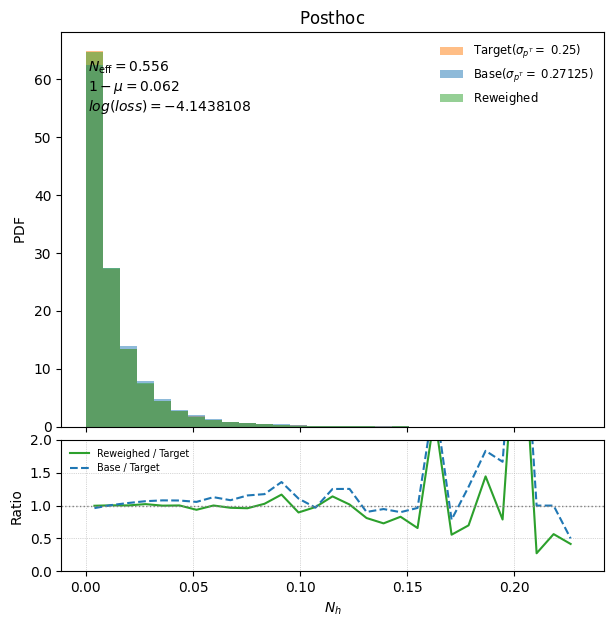

In [85]:
import matplotlib.pyplot as plt
import numpy as np
print(N_events)

# obs_exp_plot = charged_mult_exp
# obs_sim_plot = charged_mult_sim
# obs_exp_plot = mult_exp
# obs_sim_plot = mult_sim
print(torch.as_tensor(obs_sim_plot))
print(sim_obs_batch)
print(torch.as_tensor(obs_sim_plot) - sim_obs_batch)

_, bins_target = np.histogram(obs_exp_plot)
_, bins_base = np.histogram(obs_sim_plot)

min_target, max_target = bins_target[0], bins_target[-1]
min_base, max_base = bins_base[0], bins_base[-1]

print(min_target, max_target)
#print(min_monash_prime, max_monash_prime)

minim = np.min([min_target, min_base])
maxim = np.max([max_target, max_base])

bins = np.linspace(minim, maxim, int((maxim - minim)+1)) #for multiplicity plots
bins = np.linspace(minim, maxim, 30) #for continuous plots

# Histogram binning and calculation
hist_target, _ = np.histogram(obs_exp_plot[0:N_events], bins=bins, density=True)
hist_base, _ = np.histogram(obs_sim_plot[0:N_events], bins=bins, density=True)
hist_reweighted, _ = np.histogram(obs_sim_plot[0:N_events], bins=bins, weights=weights, density=True)

# Bin centers for plotting
bin_centers = 0.5 * (bins[1:] + bins[:-1])

# --- Plot with Ratio subplot ---
fig, (ax_main, ax_ratio) = plt.subplots(2, 1, figsize=(7, 7), sharex=True, 
                                        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

# --- Main Histogram Plot ---
ax_main.hist(obs_exp_plot[0:N_events], bins=bins, alpha=0.5, 
             label=rf"$\mathrm{{Target}}$" + r"$(\sigma_{p^T} =$"+f" {sigma_target})", 
             color='tab:orange', density=True)
ax_main.hist(obs_sim_plot[0:N_events], bins=bins, alpha=0.5, 
             label=r'$\mathrm{Base}$' + r'$(\sigma_{p^T} =$'+f' {sigma_base})', 
             color='tab:blue', density=True)
ax_main.hist(obs_sim_plot[0:N_events], bins=bins, weights=weights, alpha=0.5, 
             label=r"$\mathrm{Reweighed}$", color='tab:green', density=True)


wasserstein_loss = WassersteinLoss(p = 1)
z=torch.tensor(obs_sim_plot[0:N_events])
w = torch.tensor(obs_exp_plot[0:N_events])
weights = torch.tensor(weights)

print(type(z), type(w))
loss = wasserstein_loss(z,w,weights)
print(loss)

# Metrics Text
ax_main.text(0.05, 0.9, rf'$N_{{\mathrm{{eff}}}} = {Neff:.3f}$', fontsize=10, transform=ax_main.transAxes)
ax_main.text(0.05, 0.85, rf'$1 - \mu = {one_minus_mu:.3f}$', fontsize=10, transform=ax_main.transAxes)
ax_main.text(0.05, 0.8, rf'$log(loss) = {np.log10(loss):.7f}$', fontsize=10, transform=ax_main.transAxes)

# Axis Labels and Title
ax_main.set_ylabel(r'$\mathrm{PDF}$')
ax_main.legend(frameon=False, fontsize='small')
ax_main.set_title(r'$\mathrm{Posthoc}$')

# --- Ratio Plot ---
# Avoid divide-by-zero
with np.errstate(divide='ignore', invalid='ignore'):
    ratio_rw = np.divide(hist_reweighted, hist_target, out=np.zeros_like(hist_reweighted), where=hist_target != 0)
    ratio_base = np.divide(hist_base, hist_target, out=np.zeros_like(hist_base), where=hist_target != 0)

ax_ratio.plot(bin_centers, ratio_rw, color='tab:green', label='Reweighed / Target')
ax_ratio.plot(bin_centers, ratio_base, color='tab:blue', linestyle='--', label='Base / Target')
ax_ratio.axhline(1.0, color='gray', linestyle=':', linewidth=1)

ax_ratio.set_xlabel(r'$N_h$')
ax_ratio.set_ylabel('Ratio')
ax_ratio.set_ylim(0, 2)  # Adjust if needed
ax_ratio.legend(frameon=False, fontsize='x-small')
ax_ratio.grid(True, linestyle=':', linewidth=0.5)

# --- Final layout and save ---
fig.tight_layout()
# plt.savefig('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Flow_map_nD/' + '3from0.335_t00.325.png')
plt.show()


100000
tensor([0.0099, 0.0151, 0.0091,  ..., 0.0465, 0.0133, 0.0365],
       dtype=torch.float64)
tensor([0.0099, 0.0151, 0.0091,  ..., 0.0465, 0.0133, 0.0365])
tensor([ 2.2719e-10, -3.5766e-10, -2.4314e-10,  ...,  1.4441e-09,
        -3.5861e-10, -4.0430e-10], dtype=torch.float64)
0.0008500425417002353 0.20782282302140007
<class 'torch.Tensor'> <class 'torch.Tensor'>
tensor(7.4778e-05, dtype=torch.float64)


/tmp/ipykernel_288878/3070414807.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  weights = torch.tensor(weights)
/tmp/ipykernel_288878/3070414807.py:62: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  ax_main.text(0.05, 0.8, rf'$log(loss) = {np.log10(loss):.7f}$', fontsize=10, transform=ax_main.transAxes)
/tmp/ipykernel_288878/3070414807.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_main.legend(frameon=False, fontsize='small')
/tmp/ipykernel_288878/3070414807.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


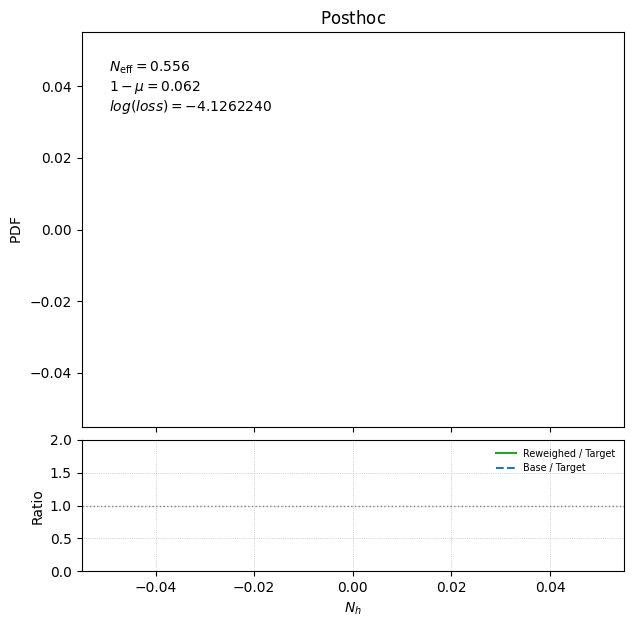

In [78]:
import matplotlib.pyplot as plt
import numpy as np
print(N_events)

# obs_exp_plot = charged_mult_exp
# obs_sim_plot = charged_mult_sim
# obs_exp_plot = mult_exp
# obs_sim_plot = mult_sim
print(torch.as_tensor(obs_sim_plot))
print(sim_obs_batch)
print(torch.as_tensor(obs_sim_plot) - sim_obs_batch)

_, bins_target = np.histogram(obs_exp_plot)
_, bins_base = np.histogram(obs_sim_plot)

min_target, max_target = bins_target[0], bins_target[-1]
min_base, max_base = bins_base[0], bins_base[-1]

print(min_target, max_target)
#print(min_monash_prime, max_monash_prime)

minim = np.min([min_target, min_base])
maxim = np.max([max_target, max_base])

bins = np.linspace(minim, maxim, int((maxim - minim)+1))

# Histogram binning and calculation
hist_target, _ = np.histogram(obs_exp_plot[0:N_events], bins=bins, density=True)
hist_base, _ = np.histogram(obs_sim_plot[0:N_events], bins=bins, density=True)
hist_reweighted, _ = np.histogram(obs_sim_plot[0:N_events], bins=bins, weights=weights, density=True)

# Bin centers for plotting
bin_centers = 0.5 * (bins[1:] + bins[:-1])

# --- Plot with Ratio subplot ---
fig, (ax_main, ax_ratio) = plt.subplots(2, 1, figsize=(7, 7), sharex=True, 
                                        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

# --- Main Histogram Plot ---
ax_main.hist(obs_exp_plot[0:N_events], bins=bins, alpha=0.5, 
             label=rf"$\mathrm{{Target}}$" + r"$(\sigma_{p^T} =$"+f" {sigma_target})", 
             color='tab:orange', density=True)
ax_main.hist(obs_sim_plot[0:N_events], bins=bins, alpha=0.5, 
             label=r'$\mathrm{Base}$' + r'$(\sigma_{p^T} =$'+f' {sigma_base})', 
             color='tab:blue', density=True)
ax_main.hist(obs_sim_plot[0:N_events], bins=bins, weights=weights, alpha=0.5, 
             label=r"$\mathrm{Reweighed}$", color='tab:green', density=True)


wasserstein_loss = WassersteinLoss(p = 1)
z=torch.tensor(obs_sim_plot[0:N_events])
w = torch.tensor(obs_exp_plot[0:N_events])
weights = torch.tensor(weights)

print(type(z), type(w))
loss = wasserstein_loss(z,w,weights)
print(loss)

# Metrics Text
ax_main.text(0.05, 0.9, rf'$N_{{\mathrm{{eff}}}} = {Neff:.3f}$', fontsize=10, transform=ax_main.transAxes)
ax_main.text(0.05, 0.85, rf'$1 - \mu = {one_minus_mu:.3f}$', fontsize=10, transform=ax_main.transAxes)
ax_main.text(0.05, 0.8, rf'$log(loss) = {np.log10(loss):.7f}$', fontsize=10, transform=ax_main.transAxes)

# Axis Labels and Title
ax_main.set_ylabel(r'$\mathrm{PDF}$')
ax_main.legend(frameon=False, fontsize='small')
ax_main.set_title(r'$\mathrm{Posthoc}$')

# --- Ratio Plot ---
# Avoid divide-by-zero
with np.errstate(divide='ignore', invalid='ignore'):
    ratio_rw = np.divide(hist_reweighted, hist_target, out=np.zeros_like(hist_reweighted), where=hist_target != 0)
    ratio_base = np.divide(hist_base, hist_target, out=np.zeros_like(hist_base), where=hist_target != 0)

ax_ratio.plot(bin_centers, ratio_rw, color='tab:green', label='Reweighed / Target')
ax_ratio.plot(bin_centers, ratio_base, color='tab:blue', linestyle='--', label='Base / Target')
ax_ratio.axhline(1.0, color='gray', linestyle=':', linewidth=1)

ax_ratio.set_xlabel(r'$N_h$')
ax_ratio.set_ylabel('Ratio')
ax_ratio.set_ylim(0, 2)  # Adjust if needed
ax_ratio.legend(frameon=False, fontsize='x-small')
ax_ratio.grid(True, linestyle=':', linewidth=0.5)

# --- Final layout and save ---
fig.tight_layout()
# plt.savefig('/pscratch/sd/l/ljpuslar/RSA/RSA/src/temp_results/Flow_map_nD/' + '3from0.335_t00.325.png')
plt.show()